# Examen Machine Learning I

**Estudiante:** Diego Castillo
**Asignatura:** Machine Learning I — Escuela de Ingeniería, Universidad Mayor
**Fecha:** 7 de septiembre de 2026

---

### Declaración del dataset

| Campo | Detalle |
|---|---|
| **Nombre** | California Housing |
| **Fuente** | scikit-learn (`sklearn.datasets.fetch_california_housing`), construido sobre el censo de EE.UU. de 1990 (Pace & Barry, 1997) |
| **URL** | https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset |
| **Filas** | 20.640 distritos censales |
| **Columnas** | 8 predictoras numéricas continuas + 1 variable objetivo (más 2 categóricas que construyo en la sección 1.1) |
| **Variable objetivo** | `MedHouseVal` — valor medio de la vivienda del distrito, en cientos de miles de USD |
| **Tipo de tarea** | Regresión |

Elegí este dataset porque cumple con holgura los mínimos exigidos (20.640 observaciones frente a las 500 pedidas, 8 predictoras frente a 6), viene con URL pública verificable, y al ser un problema de regresión con una variable objetivo continua me permite trabajar las métricas RMSE, MAE, R² y MAPE que pide la pauta.

> **Declaración de uso de IA generativa:** utilicé un asistente de IA (Claude, Anthropic) como apoyo para estructurar el pipeline, ordenar el código y revisar la redacción de las interpretaciones. La ejecución, la verificación de los resultados y las decisiones metodológicas las hice y validé yo.

In [1]:
# Librerías que voy a usar en todo el notebook
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

# Carpeta donde guardo todas las figuras que pide la pauta
os.makedirs("figures", exist_ok=True)

# Semilla fija para que todo el notebook sea reproducible
SEED = 42
np.random.seed(SEED)

## 1. Carga del dataset

In [2]:
from sklearn.datasets import fetch_california_housing

# Este dataset viene dentro de sklearn, así que no necesito montar Drive ni descargar nada
data = fetch_california_housing(as_frame=True)
df = data.frame.copy()

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 1.1 Feature engineering: creo dos variables categóricas

El dataset original es **100% numérico**, así que tal cual viene no me permite aplicar `OneHotEncoder` ni `OrdinalEncoder`, que son parte obligatoria del pipeline de preprocesamiento. Para poder demostrar esas dos técnicas construyo dos variables categóricas a partir de columnas que ya existen:

1. **`age_group` (ordinal):** agrupo `HouseAge` en Nueva (menos de 15 años), Media (15 a 35) y Antigua (más de 35). Tiene un orden natural, por eso la trato como ordinal.
2. **`region` (nominal):** agrupo `Latitude` en Norte (sobre 37.5°), Centro (entre 35° y 37.5°) y Sur (bajo 35°), aproximando las macrozonas de California. No hay un orden intrínseco entre ellas, por eso va como nominal.

Dejo las variables originales (`HouseAge` y `Latitude`) dentro del set de predictoras, aunque eso genere redundancia con las categóricas nuevas. Lo hago a propósito: las versiones continuas tienen más información que las agrupadas, y prefiero no perderla. Más adelante, al ver la importancia de variables, esta decisión se va a notar.

In [3]:
# Variable ORDINAL: agrupo la antigüedad de la vivienda en tres tramos
def age_bucket(v):
    if v < 15:
        return "Nueva"
    elif v < 35:
        return "Media"
    else:
        return "Antigua"

df["age_group"] = df["HouseAge"].apply(age_bucket)

# Variable NOMINAL: uso la latitud para aproximar la macrozona de California
def region_bucket(lat):
    if lat > 37.5:
        return "Norte"
    elif lat > 35.0:
        return "Centro"
    else:
        return "Sur"

df["region"] = df["Latitude"].apply(region_bucket)

# Reviso cómo quedaron distribuidas
print("Distribución de age_group (%):")
print((df["age_group"].value_counts(normalize=True) * 100).round(2))
print("\nDistribución de region (%):")
print((df["region"].value_counts(normalize=True) * 100).round(2))

Distribución de age_group (%):
age_group
Media      51.83
Antigua    34.73
Nueva      13.44
Name: proportion, dtype: float64

Distribución de region (%):
region
Sur       54.72
Norte     29.72
Centro    15.56
Name: proportion, dtype: float64


## 2. Exploración inicial

In [4]:
# Dimensiones del dataset
df.shape

(20640, 11)

In [5]:
# Tipos de dato de cada columna
df.dtypes

,0
MedInc,float64
HouseAge,float64
AveRooms,float64
AveBedrms,float64
Population,float64
AveOccup,float64
Latitude,float64
Longitude,float64
MedHouseVal,float64
age_group,object


In [6]:
# Info general: conteo de no-nulos y uso de memoria
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
 9   age_group    20640 non-null  object 
 10  region       20640 non-null  object 
dtypes: float64(9), object(2)
memory usage: 1.7+ MB


In [7]:
# Estadísticos descriptivos de las variables numéricas
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Lo primero que me llama la atención en el `describe()` es el máximo de `MedHouseVal`: **5.000010**. Ese número tan exacto no es casualidad, es un **tope artificial** — el censo de EE.UU. trunca en 500.001 USD todos los distritos que valen más. Lo dejo anotado porque más adelante explica buena parte de los errores más grandes del modelo.

También veo valores extremos evidentes: `AveRooms` llega a **141.9** habitaciones promedio y `AveOccup` a **1.243** ocupantes por hogar. Eso lo reviso en la sección de *outliers*.

## 3. Valores faltantes

Porcentaje de nulos por columna:
MedInc         0.0
HouseAge       0.0
AveRooms       0.0
AveBedrms      0.0
Population     0.0
AveOccup       0.0
Latitude       0.0
Longitude      0.0
MedHouseVal    0.0
age_group      0.0
region         0.0
dtype: float64


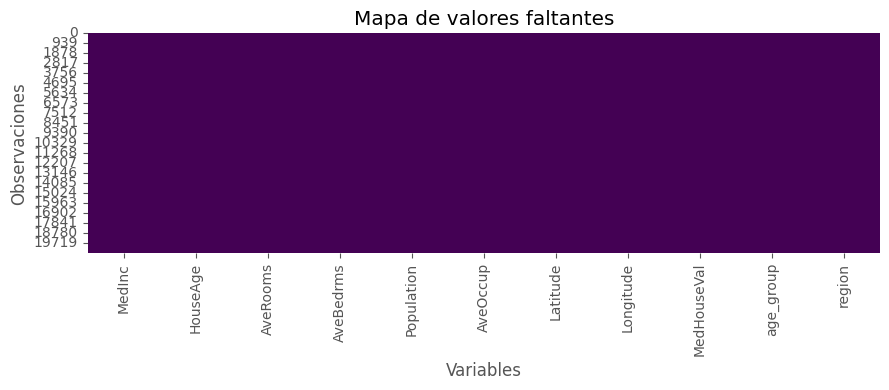

In [8]:
# Porcentaje de nulos por columna
porcentaje_nulos = (df.isnull().mean() * 100).round(2)
print("Porcentaje de nulos por columna:")
print(porcentaje_nulos)

# Mapa visual para confirmar que no hay huecos escondidos
plt.figure(figsize=(9,4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Mapa de valores faltantes")
plt.xlabel("Variables")
plt.ylabel("Observaciones")
plt.tight_layout()
plt.savefig("figures/missing_heatmap.png", dpi=150)
plt.show()

**No hay ningún valor faltante:** las 11 columnas tienen **0.00%** de nulos, y el mapa se ve completamente uniforme, sin las franjas que aparecerían si hubiera huecos.

Por lo tanto **no imputo ni elimino nada**. Aun así, más adelante dejo un `SimpleImputer` dentro del `ColumnTransformer` (mediana para numéricas, moda para categóricas). Lo hago como resguardo: si mañana este mismo pipeline recibe datos nuevos que sí traigan nulos, no se cae.

## 4. Detección y tratamiento de outliers (método IQR)

In [9]:
# Aplico IQR sobre las cuatro variables numéricas donde el describe() mostró valores extremos
key_cols = ["AveRooms", "AveBedrms", "Population", "AveOccup"]

outlier_info = {}
df_treated = df.copy()

for col in key_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    pct_out = ((df[col] < low) | (df[col] > high)).mean() * 100
    outlier_info[col] = {"limite_inf": round(low, 3),
                          "limite_sup": round(high, 3),
                          "pct_outliers": round(pct_out, 2)}
    # Capping: en vez de borrar la fila, llevo el valor extremo al límite
    df_treated[col] = df_treated[col].clip(lower=low, upper=high)

pd.DataFrame(outlier_info).T

,limite_inf,limite_sup,pct_outliers
AveRooms,2.023,8.470,2.48
AveBedrms,0.866,1.240,6.90
Population,-620.000,3132.000,5.79
AveOccup,1.151,4.561,3.44


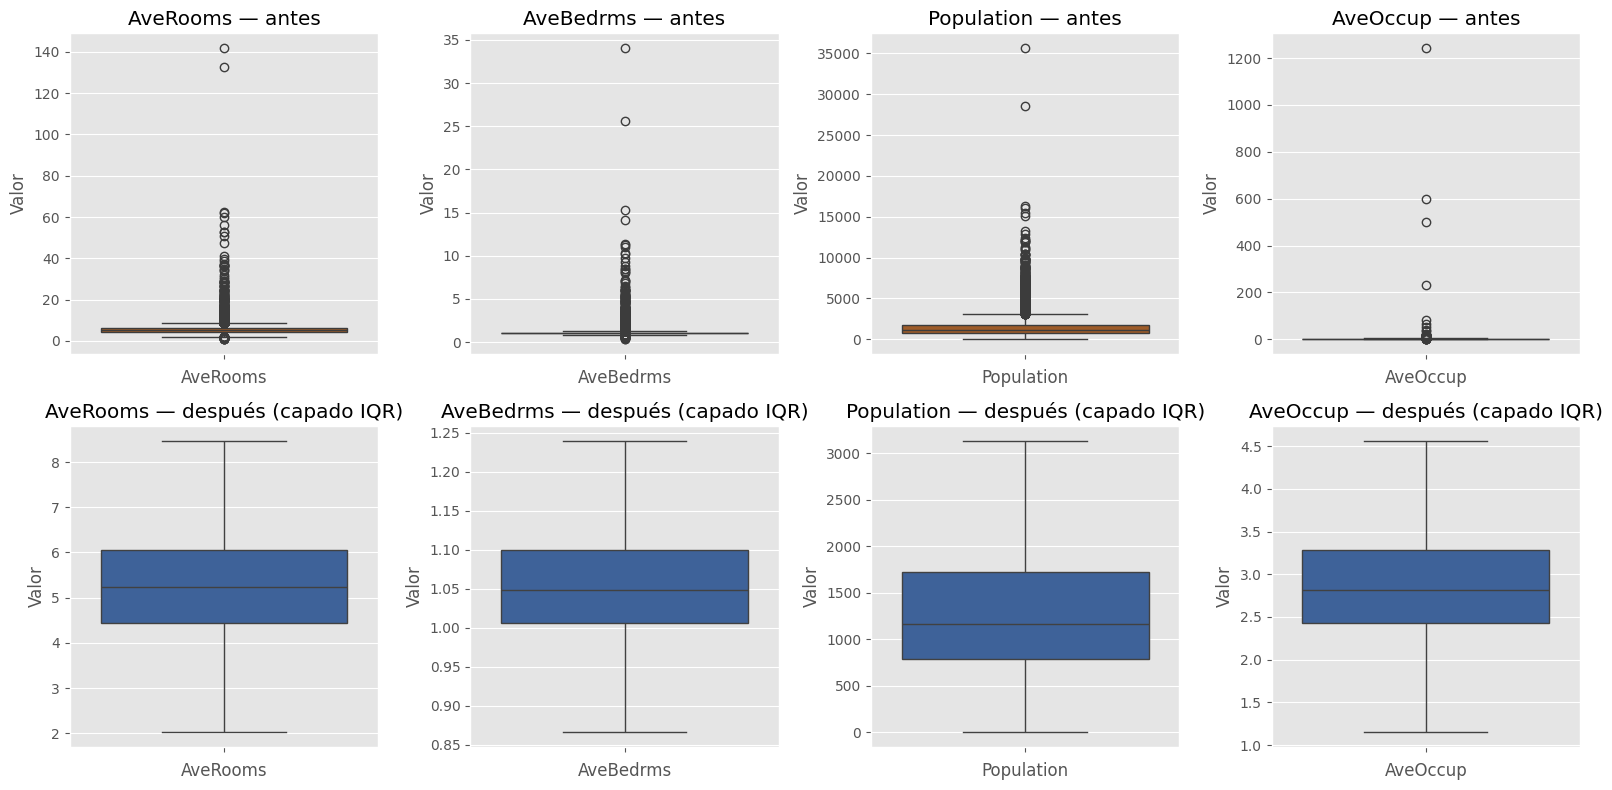

In [10]:
# Comparo la distribución antes y después del capping
fig, axes = plt.subplots(2, len(key_cols), figsize=(16,8))

for i, col in enumerate(key_cols):
    sns.boxplot(y=df[col], ax=axes[0,i], color="#B15A16")
    axes[0,i].set_title(f"{col} — antes")
    axes[0,i].set_ylabel("Valor")
    axes[0,i].set_xlabel(col)

    sns.boxplot(y=df_treated[col], ax=axes[1,i], color="#2F5FA8")
    axes[1,i].set_title(f"{col} — después (capado IQR)")
    axes[1,i].set_ylabel("Valor")
    axes[1,i].set_xlabel(col)

plt.tight_layout()
plt.savefig("figures/boxplots_outliers.png", dpi=150)
plt.show()

# Me quedo con la versión tratada
df = df_treated

**Cuánto encontré:** `AveBedrms` es la más afectada con **6.90%** de *outliers*, seguida de `Population` (**5.79%**), `AveOccup` (**3.44%**) y `AveRooms` (**2.48%**).

**Qué decidí y por qué:** opté por **capar (winsorizar)** en los límites IQR, no por eliminar ni imputar. Mi razonamiento fue:

1. **No son errores de captura.** Un distrito con 1.243 ocupantes promedio por hogar probablemente sea una zona con población institucional (un campus, un recinto). Es un dato raro, pero real.
2. **Eliminar filas me costaría cobertura geográfica.** Al borrar el 6.9% de los distritos perdería zonas completas del mapa, y la ubicación resultó ser justamente una de las variables importantes.
3. **Capar conserva las 20.640 filas** y al mismo tiempo evita que un puñado de valores extremos arrastre el escalado y los coeficientes del modelo lineal.

En los boxplots de abajo se nota el efecto: antes del tratamiento las cajas quedaban aplastadas contra el eje porque unos pocos puntos estiraban toda la escala; después las distribuciones se leen con claridad.

> **Nota metodológica sobre fuga de datos.** Los límites IQR los calculé sobre el dataset completo, antes de separar train y test. Lo hice así porque la pauta ordena el tratamiento de *outliers* (paso 6) antes de la partición (paso 10), y porque a esta altura es parte del análisis exploratorio. Soy consciente de que el criterio más estricto sería calcular los cuartiles solo con `X_train` y aplicar esos mismos límites al test. Con 20.640 observaciones el efecto es marginal, pero lo dejo declarado. En cambio, **todo el preprocesamiento del pipeline (imputación, escalado y codificación) sí lo ajusto exclusivamente con train**, que es donde el riesgo de fuga es real.

## 5. Análisis de la variable objetivo

Skewness de MedHouseVal: 0.9777
Skewness si aplicara log1p: 0.2759

Distritos en el tope de censura (5.00001): 992 (4.81% del dataset)


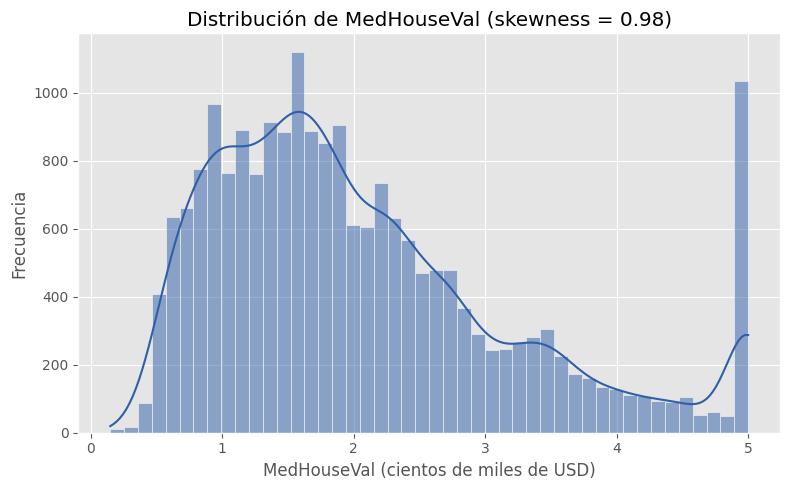

In [11]:
from scipy.stats import skew

skew_original = skew(df["MedHouseVal"])
skew_log = skew(np.log1p(df["MedHouseVal"]))

print(f"Skewness de MedHouseVal: {skew_original:.4f}")
print(f"Skewness si aplicara log1p: {skew_log:.4f}")

# Cuantifico el tope de censura que detecté en el describe()
censurados = (df["MedHouseVal"] >= 5.0).sum()
print(f"\nDistritos en el tope de censura (5.00001): {censurados} ({censurados/len(df)*100:.2f}% del dataset)")

plt.figure(figsize=(8,5))
sns.histplot(df["MedHouseVal"], kde=True, color="#2F5FA8")
plt.title(f"Distribución de MedHouseVal (skewness = {skew_original:.2f})")
plt.xlabel("MedHouseVal (cientos de miles de USD)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("figures/target_dist.png", dpi=150)
plt.show()

El *skewness* me da **0.98**, es decir, la distribución está sesgada hacia la derecha pero **queda justo por debajo del umbral de 1.0** que la pauta define para evaluar una transformación logarítmica. Por poco, pero no lo cruza.

De todas formas hice la prueba: aplicando `log1p` el *skewness* bajaría a **0.28**, o sea la transformación sí funcionaría. **Aun así decido mantener la escala original**, por dos razones:

1. El criterio de la pauta no se activa (0.98 < 1.0).
2. Si transformo el objetivo, el RMSE y el MAE dejan de estar en dólares y pasan a estar en unidades logarítmicas, lo que me complica interpretar el error en términos de negocio. Prefiero poder decir "me equivoco en promedio 33 mil dólares" antes que un número sin unidad clara.

En el histograma también se ve con claridad la **barra alta pegada al extremo derecho, en 5.0**: son los distritos censurados por el tope de 500.001 USD que mencioné antes. No es una cola natural, es un artefacto del dataset, y lo cuantifiqué: son **992 distritos, el 4.81%** del total. Ese casi 5% de observaciones con etiqueta truncada va a reaparecer al final, cuando analice dónde falla más el modelo.

## 6. Correlaciones y multicolinealidad

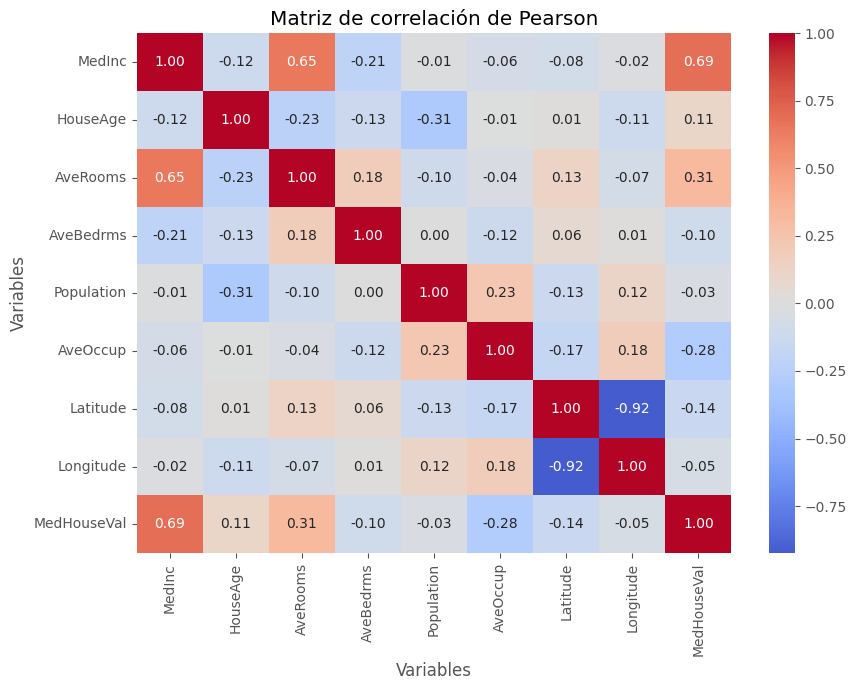

Top 5 correlacionadas con MedHouseVal (valor absoluto):
MedInc      0.688
AveRooms    0.311
AveOccup    0.281
Latitude    0.144
HouseAge    0.106
Name: MedHouseVal, dtype: float64

Pares de predictores con |r| > 0.85:
  Latitude - Longitude: r = -0.925


In [12]:
numeric_cols = ["MedInc","HouseAge","AveRooms","AveBedrms","Population","AveOccup","Latitude","Longitude"]

corr = df[numeric_cols + ["MedHouseVal"]].corr(method="pearson")

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de Pearson")
plt.xlabel("Variables")
plt.ylabel("Variables")
plt.tight_layout()
plt.savefig("figures/corr_heatmap.png", dpi=150)
plt.show()

# Top 5 variables más correlacionadas con el objetivo (en valor absoluto)
top5 = corr["MedHouseVal"].drop("MedHouseVal").abs().sort_values(ascending=False).head(5)
print("Top 5 correlacionadas con MedHouseVal (valor absoluto):")
print(top5.round(3))

# Busco pares de predictores con multicolinealidad (r > 0.85)
print("\nPares de predictores con |r| > 0.85:")
encontrados = 0
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        r = corr.loc[numeric_cols[i], numeric_cols[j]]
        if abs(r) > 0.85:
            print(f"  {numeric_cols[i]} - {numeric_cols[j]}: r = {r:.3f}")
            encontrados += 1
if encontrados == 0:
    print("  No encontré ninguno.")

**Las 5 variables más correlacionadas con el valor de la vivienda:**

| # | Variable | \|r\| |
|---|---|---|
| 1 | `MedInc` | 0.688 |
| 2 | `AveRooms` | 0.311 |
| 3 | `AveOccup` | 0.281 |
| 4 | `Latitude` | 0.144 |
| 5 | `HouseAge` | 0.106 |

El ingreso medio del distrito domina por completo: **0.688 contra 0.311** de la segunda. La brecha entre la primera y la segunda es más grande que la que hay entre la segunda y la última del ranking.

**Multicolinealidad:** encontré un único par sobre el umbral, `Latitude` y `Longitude`, con **r = -0.925**. Es totalmente esperable, porque California es un estado alargado en diagonal: a medida que bajas en latitud también te mueves en longitud, así que ambas coordenadas describen casi la misma información posicional.

**Decido no eliminar ninguna de las dos.** Para el Random Forest la redundancia no es un problema (los árboles pueden usar ambas para delimitar zonas geográficas), y para el modelo lineal la penalización L2 de Ridge está diseñada precisamente para repartir el peso entre predictores correlacionados en vez de volverse inestable.

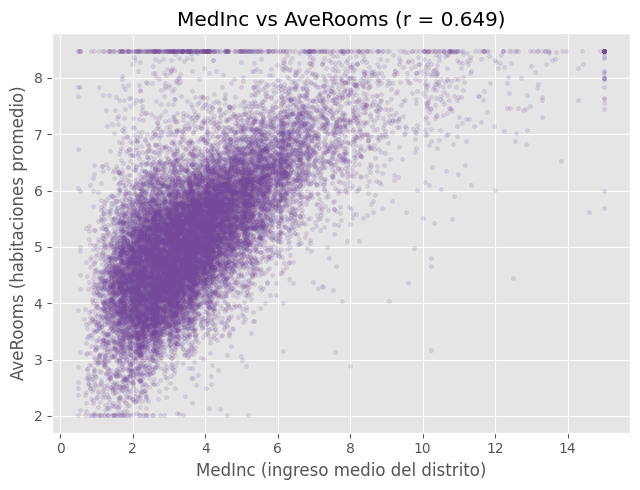

In [13]:
# Scatter 1: las dos variables MÁS correlacionadas con el objetivo, graficadas entre sí
plt.figure(figsize=(6.5,5))
plt.scatter(df["MedInc"], df["AveRooms"], alpha=0.15, s=8, color="#74499A")
plt.title(f"MedInc vs AveRooms (r = {df['MedInc'].corr(df['AveRooms']):.3f})")
plt.xlabel("MedInc (ingreso medio del distrito)")
plt.ylabel("AveRooms (habitaciones promedio)")
plt.tight_layout()
plt.savefig("figures/scatter_top2_variables.png", dpi=150)
plt.show()

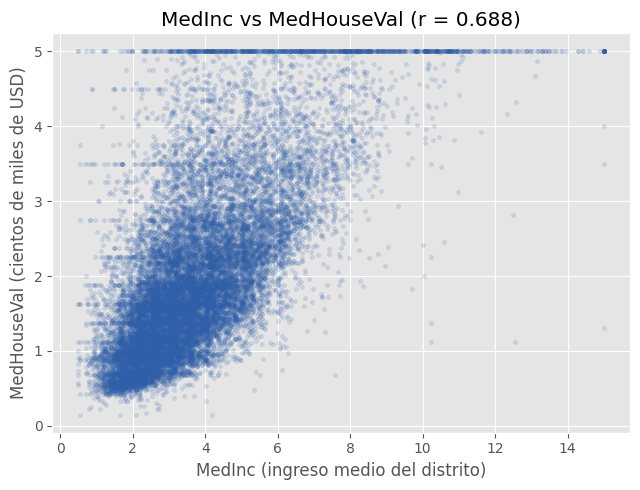

In [14]:
# Scatter 2: la variable más correlacionada contra el objetivo
plt.figure(figsize=(6.5,5))
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.15, s=8, color="#2F5FA8")
plt.title("MedInc vs MedHouseVal (r = 0.688)")
plt.xlabel("MedInc (ingreso medio del distrito)")
plt.ylabel("MedHouseVal (cientos de miles de USD)")
plt.tight_layout()
plt.savefig("figures/scatter_top_corr.png", dpi=150)
plt.show()

En el primer gráfico las dos variables top del ranking se relacionan entre sí con **r = 0.649**: los distritos de mayor ingreso tienden a tener casas más grandes. Esto lo retomo al final, porque explica por qué `AveRooms` termina aportando mucho menos de lo que su correlación individual sugería.

En el segundo se ve la relación positiva clara entre ingreso y valor de la vivienda, y también se aprecia perfectamente **la línea horizontal de puntos en 5.0**: los distritos censurados por el tope del censo.

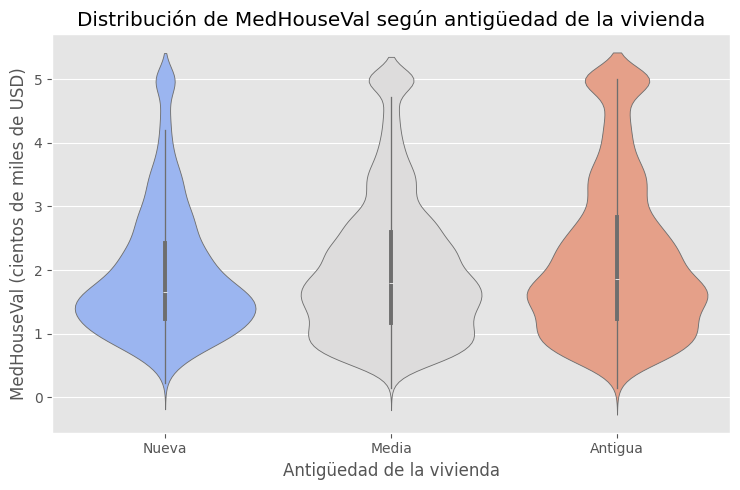

In [15]:
# Tercera visualización: violin plot del objetivo según la antigüedad de la vivienda
plt.figure(figsize=(7.5,5))
sns.violinplot(x="age_group", y="MedHouseVal", data=df,
               order=["Nueva","Media","Antigua"], palette="coolwarm")
plt.title("Distribución de MedHouseVal según antigüedad de la vivienda")
plt.xlabel("Antigüedad de la vivienda")
plt.ylabel("MedHouseVal (cientos de miles de USD)")
plt.tight_layout()
plt.savefig("figures/violin_age_group.png", dpi=150)
plt.show()

El violín me muestra algo que no esperaba: las viviendas **Antiguas** no valen menos que las Nuevas, al contrario, su distribución está levemente desplazada hacia arriba y tiene más masa en la parte alta. La explicación más razonable es que los barrios antiguos de California son justamente los consolidados y mejor ubicados (centros urbanos, zonas costeras), mientras que la construcción nueva tiende a estar en la periferia. La antigüedad, por sí sola, no es un indicador de deterioro.

## 7. Partición train / test

In [16]:
from sklearn.model_selection import train_test_split

feature_cols = numeric_cols + ["age_group", "region"]
X = df[feature_cols]
y = df["MedHouseVal"]

# Separo ANTES de imputar, escalar o codificar: el test tiene que quedar intacto
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print(f"Proporción del test: {len(X_test)/len(X)*100:.1f}%")

X_train: (16512, 10)
X_test:  (4128, 10)
Proporción del test: 20.0%


Separo **antes de cualquier transformación del pipeline**. Este es el punto donde se juega la validez de todo el examen: si escalara o imputara con el dataset completo, la media y la desviación estándar usadas para transformar el test ya contendrían información del test, y las métricas finales estarían infladas. Quedan **16.512 filas para entrenar (80%)** y **4.128 para evaluar (20%)**.

## 8. Preprocesamiento con ColumnTransformer

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

ordinal_col = ["age_group"]
nominal_col = ["region"]

preprocessor = ColumnTransformer(transformers=[
    # Numéricas: imputo con la mediana (robusta a extremos) y estandarizo
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_cols),

    # Ordinal: le paso el orden explícito para que Nueva < Media < Antigua
    ("ord", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("enc", OrdinalEncoder(categories=[["Nueva","Media","Antigua"]]))
    ]), ordinal_col),

    # Nominal: one-hot, porque entre Norte/Centro/Sur no hay orden
    ("nom", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("enc", OneHotEncoder(handle_unknown="ignore"))
    ]), nominal_col),
])

# Ajusto SOLO con train y luego aplico esa misma transformación al test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

feat_names = numeric_cols + ordinal_col + list(
    preprocessor.named_transformers_["nom"].named_steps["enc"].get_feature_names_out(nominal_col)
)

print("X_train_prep:", X_train_prep.shape)
print("X_test_prep: ", X_test_prep.shape)
print("\nVariables después del ColumnTransformer:")
print(feat_names)

X_train_prep: (16512, 12)
X_test_prep:  (4128, 12)

Variables después del ColumnTransformer:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'age_group', 'region_Centro', 'region_Norte', 'region_Sur']


El detalle clave está en las dos últimas líneas de código: uso **`fit_transform` en train** y **solo `transform` en test**. El `fit` es el que aprende los parámetros (la mediana de cada columna, la media y desviación para escalar, las categorías para codificar), y esos parámetros tienen que salir únicamente del conjunto de entrenamiento.

Las 10 columnas de entrada quedan en **12 columnas** después de la transformación: las 8 numéricas se mantienen, `age_group` pasa a ser una sola columna con valores 0/1/2, y `region` se abre en tres columnas binarias (`region_Centro`, `region_Norte`, `region_Sur`).

## 9. Reducción de dimensionalidad con PCA

 Componente  Varianza explicada (%)  Varianza acumulada (%)
          1                   26.78                   26.78
          2                   20.71                   47.49
          3                   16.12                   63.61
          4                   13.08                   76.69
          5                    9.71                   86.40
          6                    7.26                   93.65
          7                    2.67                   96.32
          8                    2.06                   98.38
          9                    0.75                   99.13
         10                    0.58                   99.71
         11                    0.29                  100.00
         12                    0.00                  100.00


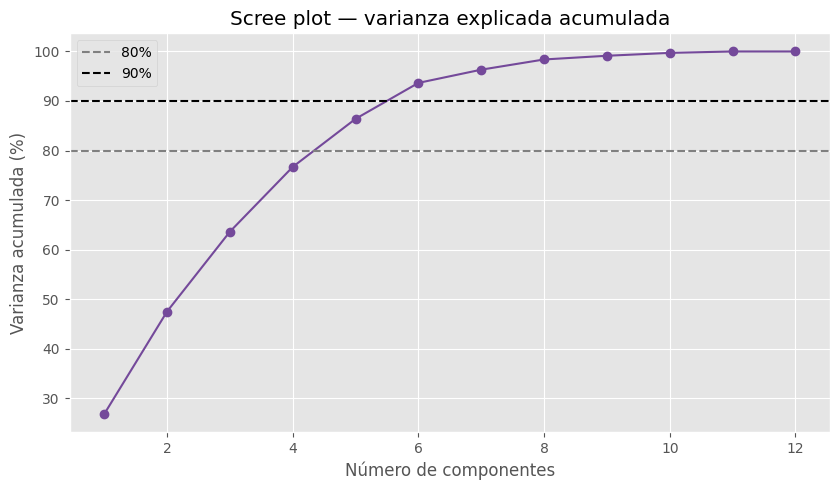

In [18]:
from sklearn.decomposition import PCA

# Primero ajusto un PCA completo para ver cuánta varianza aporta cada componente
pca_full = PCA(random_state=SEED).fit(X_train_prep)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

tabla_pca = pd.DataFrame({
    "Componente": range(1, len(explained)+1),
    "Varianza explicada (%)": (explained*100).round(2),
    "Varianza acumulada (%)": (cumulative*100).round(2)
})
print(tabla_pca.to_string(index=False))

plt.figure(figsize=(8.5,5))
plt.plot(range(1, len(cumulative)+1), cumulative*100, marker="o", color="#74499A")
plt.axhline(80, color="gray", linestyle="--", label="80%")
plt.axhline(90, color="black", linestyle="--", label="90%")
plt.title("Scree plot — varianza explicada acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada (%)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/pca_scree.png", dpi=150)
plt.show()

**Elijo `n_components = 5`.** La pauta pide quedarme en el rango de 80% a 90% de varianza explicada, y en la tabla se ve que:

- Con **5 componentes** llego a **86.40%** → cae justo dentro del rango.
- Con 6 componentes saltaría a **93.65%**, que ya se pasa del 90%.

Así que 5 es la única opción que cumple. Bajo de 12 variables a 5 componentes perdiendo apenas un 13.6% de la información, lo que me parece un intercambio razonable.

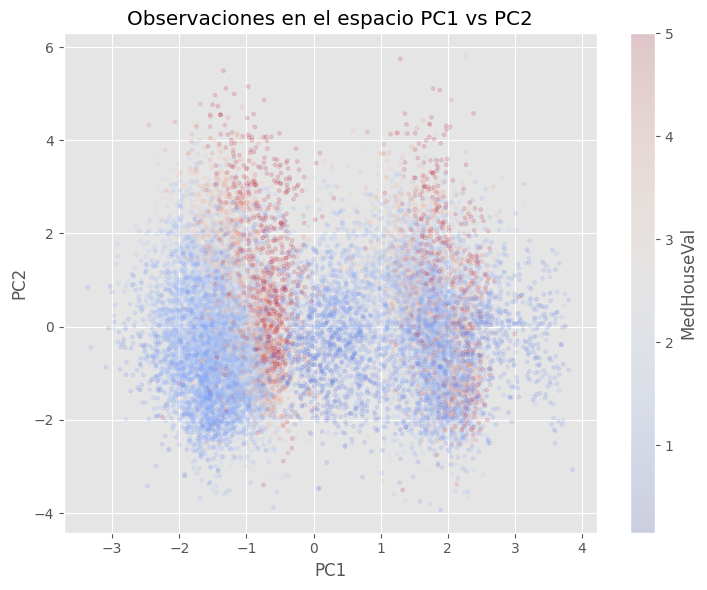

Top 5 variables que más aportan a PC1:
Latitude        0.613
Longitude       0.608
region_Sur      0.290
region_Norte    0.241
AveOccup        0.217
Name: PC1, dtype: float64

Top 5 variables que más aportan a PC2:
AveRooms      0.569
HouseAge      0.525
MedInc        0.495
age_group     0.330
Population    0.176
Name: PC2, dtype: float64


In [19]:
n_components_chosen = 5
pca = PCA(n_components=n_components_chosen, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_prep)

plt.figure(figsize=(7.5,6))
sc = plt.scatter(X_train_pca[:,0], X_train_pca[:,1],
                 alpha=0.15, s=8, c=y_train, cmap="coolwarm")
plt.colorbar(sc, label="MedHouseVal")
plt.title("Observaciones en el espacio PC1 vs PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("figures/pca_scatter.png", dpi=150)
plt.show()

# Loadings: qué variables pesan más en cada componente
loadings = pd.DataFrame(pca.components_.T, index=feat_names,
                        columns=[f"PC{i+1}" for i in range(n_components_chosen)])

print("Top 5 variables que más aportan a PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(5).round(3))
print("\nTop 5 variables que más aportan a PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(5).round(3))

Los *loadings* dejan bastante claro qué representa cada componente:

- **PC1 → ubicación.** Lo dominan `Latitude` (0.613), `Longitude` (0.608) y las categorías de `region` (0.290 y 0.241). Este componente básicamente resume *dónde está* el distrito.
- **PC2 → perfil socioeconómico y de vivienda.** Aquí pesan `AveRooms` (0.569), `HouseAge` (0.525) y `MedInc` (0.495). Este componente resume *cómo es* el distrito: qué tan grandes son las casas, qué tan antiguas y cuánto gana la gente.

Es un resultado ordenado: el PCA separó por sí solo las dos dimensiones conceptuales del dataset, geografía por un lado y perfil socioeconómico por otro, sin que yo se lo indicara.

## 10. Clustering con K-Means

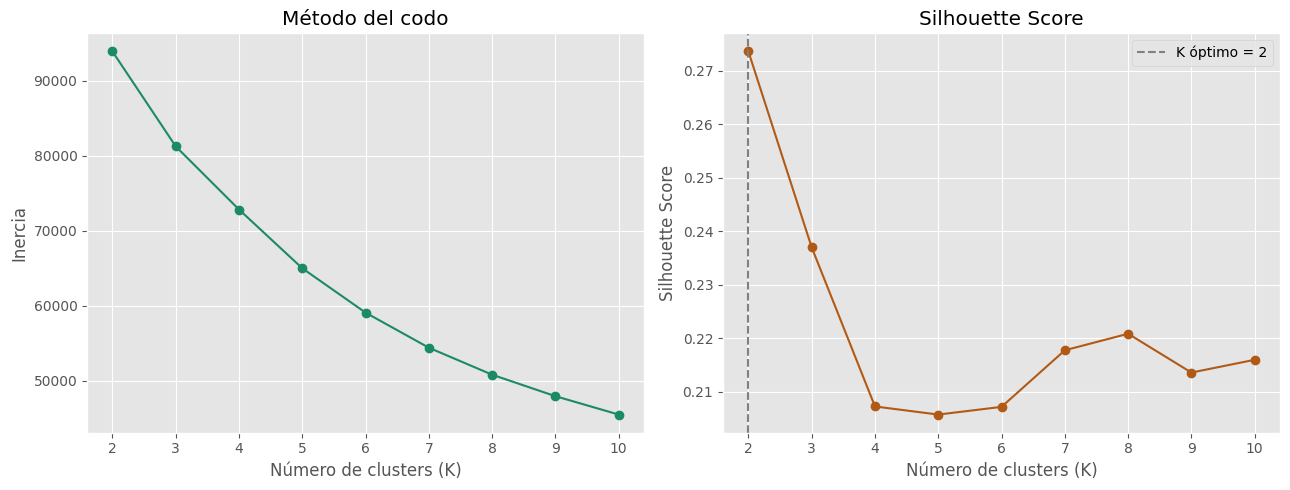

K=2: silhouette = 0.2736
K=3: silhouette = 0.2370
K=4: silhouette = 0.2073
K=5: silhouette = 0.2057
K=6: silhouette = 0.2072
K=7: silhouette = 0.2177
K=8: silhouette = 0.2208
K=9: silhouette = 0.2136
K=10: silhouette = 0.2160


In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    etiquetas = km.fit_predict(X_train_pca)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_pca, etiquetas))

fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].plot(list(K_range), inercias, marker="o", color="#1B8A66")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inercia")

axes[1].plot(list(K_range), silhouettes, marker="o", color="#B15A16")
axes[1].axvline(2, color="gray", linestyle="--", label="K óptimo = 2")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/kmeans_elbow_silhouette.png", dpi=150)
plt.show()

for k, s in zip(K_range, silhouettes):
    print(f"K={k}: silhouette = {s:.4f}")

**Elijo K = 2**, que es donde el Silhouette Score alcanza su máximo (**0.2736**) y desde ahí baja de forma sostenida.

Vale la pena ser honesto con este resultado: un Silhouette de 0.27 es **moderado-bajo**. No estoy frente a grupos nítidamente separados, sino a una nube de datos con una división suave. El método del codo tampoco muestra un quiebre pronunciado, la curva de inercia baja de manera bastante gradual.

La lectura que hago es que este dataset **no tiene una estructura de clusters marcada**, y eso en sí mismo es un hallazgo: los distritos censales de California forman un continuo más que segmentos discretos. K=2 captura la única división realmente presente, que como veo enseguida es geográfica.

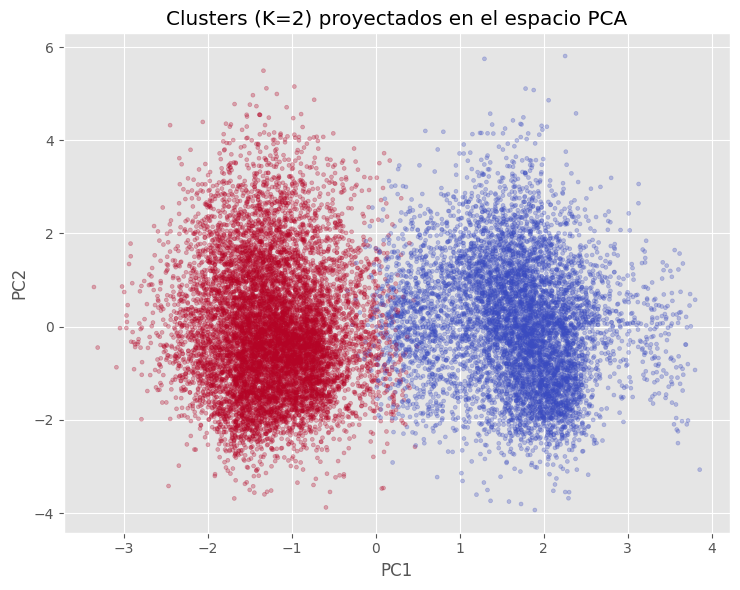

Tamaño de cada cluster (%):
Cluster
1    57.27
0    42.73
Name: proportion, dtype: float64



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
Cluster,,,,,,,,
0,3.82,28.73,5.50,1.06,1229.32,2.75,37.93,-121.7
1,3.92,28.52,5.17,1.06,1419.10,3.01,33.93,-118.0


In [21]:
kmeans_final = KMeans(n_clusters=2, random_state=SEED, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_train_pca)

plt.figure(figsize=(7.5,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=cluster_labels,
            cmap="coolwarm", alpha=0.3, s=8)
plt.title("Clusters (K=2) proyectados en el espacio PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("figures/pca_clusters.png", dpi=150)
plt.show()

# Perfil de cada cluster: media de cada variable
X_train_clustered = X_train.copy()
X_train_clustered["Cluster"] = cluster_labels

print("Tamaño de cada cluster (%):")
print((X_train_clustered["Cluster"].value_counts(normalize=True)*100).round(2))
print()

perfil = X_train_clustered.groupby("Cluster")[numeric_cols].mean().round(2)
perfil

**Perfil de los dos clusters:**

| | Cluster 0 | Cluster 1 |
|---|---|---|
| Tamaño | 42.7% | 57.3% |
| `Latitude` | 37.93 | 33.93 |
| `Longitude` | -121.70 | -118.00 |
| `Population` | 1.229 | 1.419 |
| `AveOccup` | 2.75 | 3.01 |
| `MedInc` | 3.82 | 3.92 |

La diferencia entre ambos es **casi puramente geográfica**: 4 grados completos de latitud separan sus centros. El **Cluster 0 es el Norte de California** (zona de San Francisco y la Bahía) y el **Cluster 1 es el Sur** (Los Ángeles y San Diego).

Lo interesante es lo que **no** los diferencia: el ingreso medio es prácticamente idéntico (3.82 contra 3.92) y la antigüedad de las viviendas también (28.7 contra 28.5 años). Lo único que se mueve junto con la geografía es la densidad: el Sur tiene distritos con **más población (+15%)** y **más ocupantes por hogar (+9%)**.

En términos de negocio, esto me dice que si alguien quisiera segmentar el mercado inmobiliario californiano con estos datos, la variable de segmentación natural es la zona geográfica, no el nivel socioeconómico — porque el ingreso está distribuido de forma pareja entre el norte y el sur.

## 11. Modelado supervisado

La pauta me pide al menos dos modelos: uno penalizado y uno basado en árboles. Entreno **tres**, porque quiero comparar las dos familias de ensamble entre sí:

1. **Ridge** — modelo lineal penalizado (L2). Rápido e interpretable, pero limitado a relaciones lineales.
2. **Random Forest** — *bagging*: muchos árboles profundos entrenados en paralelo sobre muestras distintas, cuyo promedio reduce la varianza.
3. **Gradient Boosting** — *boosting*: árboles chicos entrenados en secuencia, donde cada uno corrige el error que dejó el anterior. Ataca el sesgo en vez de la varianza.

Los tres con `random_state=42` y búsqueda de hiperparámetros por validación cruzada de 5 *folds*.

Una aclaración sobre por qué **no uso XGBoost ni LightGBM**, que son las implementaciones de boosting más populares hoy: la pauta exige ajustar `n_estimators`, `max_depth` y **`min_samples_split`**, y ese último parámetro solo existe en los modelos de scikit-learn. LightGBM usa `min_child_samples` y XGBoost usa `min_child_weight`, así que con ellos no podría cumplir el requisito tal como está escrito. Por eso uso el `GradientBoostingRegressor` de sklearn, que sí tiene los tres.

In [22]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Modelo penalizado: busco el mejor alpha con GridSearchCV
t0 = time.time()
ridge_grid = GridSearchCV(
    Ridge(random_state=SEED),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring="r2"
)
ridge_grid.fit(X_train_prep, y_train)
t_ridge = time.time() - t0

ridge_best = ridge_grid.best_estimator_

print("Mejores hiperparámetros (Ridge):", ridge_grid.best_params_)
print(f"Mejor R² en validación cruzada: {ridge_grid.best_score_:.4f}")
print(f"Tiempo de entrenamiento: {t_ridge:.4f} s")

Mejores hiperparámetros (Ridge): {'alpha': 1}
Mejor R² en validación cruzada: 0.6769
Tiempo de entrenamiento: 0.2188 s


El mejor `alpha` resultó ser **1**, un valor intermedio dentro de la grilla. Que no se haya ido al extremo bajo (0.001, prácticamente sin penalización) ni al extremo alto (100, penalización fuerte) me indica que hay algo de regularización útil, coherente con la multicolinealidad que detecté entre latitud y longitud.

**Ojo con las dos celdas siguientes:** el `GridSearchCV` del Random Forest prueba 12 combinaciones × 5 *folds* = **60 entrenamientos**, y cada uno levanta hasta 200 árboles. El de Gradient Boosting suma 8 combinaciones × 5 = **40 entrenamientos** más. Entre las dos tardan varios minutos. No están colgadas.

In [23]:
from sklearn.ensemble import RandomForestRegressor

# Modelo de árboles: ajusto los tres hiperparámetros que pide la pauta
t0 = time.time()
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=SEED),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [10, 20, None],
        "min_samples_split": [2, 5]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)
rf_grid.fit(X_train_prep, y_train)
t_rf = time.time() - t0

rf_best = rf_grid.best_estimator_

print("Mejores hiperparámetros (Random Forest):", rf_grid.best_params_)
print(f"Mejor R² en validación cruzada: {rf_grid.best_score_:.4f}")
print(f"Tiempo de entrenamiento (búsqueda completa): {t_rf:.4f} s")

Mejores hiperparámetros (Random Forest): {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Mejor R² en validación cruzada: 0.8050
Tiempo de entrenamiento (búsqueda completa): 1041.0836 s


La búsqueda eligió **200 árboles, sin límite de profundidad y `min_samples_split=2`**, es decir, la configuración **más flexible de toda la grilla**. Eso ya me anticipa que el modelo va a tender al sobreajuste: dejar crecer los árboles sin tope significa que pueden memorizar el entrenamiento. Lo confirmo más adelante comparando R² de train contra test.

El R² promedio en validación cruzada subió a **0.81**, muy por encima del **0.68** de Ridge.

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

# Modelo de boosting: mismos tres hiperparámetros, pero con profundidades chicas
# porque el boosting funciona encadenando aprendices débiles, no árboles profundos
t0 = time.time()
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    param_grid={
        "n_estimators": [100, 200],
        "max_depth": [3, 5],
        "min_samples_split": [2, 5]
    },
    cv=5,
    scoring="r2",
    n_jobs=-1
)
gb_grid.fit(X_train_prep, y_train)
t_gb = time.time() - t0

gb_best = gb_grid.best_estimator_

print("Mejores hiperparámetros (Gradient Boosting):", gb_grid.best_params_)
print(f"Mejor R² en validación cruzada: {gb_grid.best_score_:.4f}")
print(f"Tiempo de entrenamiento (búsqueda completa): {t_gb:.4f} s")

Mejores hiperparámetros (Gradient Boosting): {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Mejor R² en validación cruzada: 0.8307
Tiempo de entrenamiento (búsqueda completa): 321.3679 s


Acá está la diferencia de fondo entre las dos familias de ensamble, y se ve en los hiperparámetros elegidos:

- El **Random Forest** eligió `max_depth=None`, o sea árboles que crecen sin límite. Tiene sentido: en *bagging* cada árbol debe ser fuerte por sí solo, y el promedio de muchos árboles fuertes reduce la varianza.
- El **Gradient Boosting** eligió `max_depth=5`, árboles deliberadamente chicos. También tiene sentido: en *boosting* cada árbol solo tiene que corregir un poco el error del anterior, así que si lo dejo crecer demasiado sobreajusta de inmediato.

El R² en validación cruzada llegó a **0.83**, el mejor de los tres modelos. Y algo que no esperaba: **tardó menos de la mitad que el Random Forest**, a pesar de entrenar en secuencia. La razón es que sus árboles de profundidad 5 son muchísimo más baratos de construir que los árboles sin tope del bosque.

## 12. Evaluación sobre el conjunto de test

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

resultados = {}

for nombre, modelo, t_entren in [("Ridge", ridge_best, t_ridge),
                                  ("RandomForest", rf_best, t_rf),
                                  ("GradientBoosting", gb_best, t_gb)]:
    y_pred = modelo.predict(X_test_prep)
    y_pred_train = modelo.predict(X_train_prep)

    resultados[nombre] = {
        "RMSE": round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 4),
        "MAE": round(float(mean_absolute_error(y_test, y_pred)), 4),
        "R2": round(float(r2_score(y_test, y_pred)), 4),
        "MAPE": round(float(mape(y_test, y_pred)), 4),
        "R2_train": round(float(r2_score(y_train, y_pred_train)), 4),
        # Brecha train-test: mi indicador directo de sobreajuste
        "brecha_sobreajuste": round(float(r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred)), 4),
        "tiempo_entrenamiento_s": round(t_entren, 4),
    }

# Ordeno por R² que es mi métrica principal
comparacion = pd.DataFrame(resultados).T.sort_values("R2", ascending=False)

# Exporto al repositorio como pide la pauta
comparacion.to_csv("resultados_modelos.csv")

comparacion

,RMSE,MAE,R2,MAPE,R2_train,brecha_sobreajuste,tiempo_entrenamiento_s
GradientBoosting,0.4720,0.3134,0.8300,18.2099,0.9027,0.0727,321.3679
RandomForest,0.5036,0.3274,0.8064,18.9716,0.9742,0.1678,1041.0836
Ridge,0.6675,0.4881,0.6600,29.6185,0.6775,0.0175,0.2188


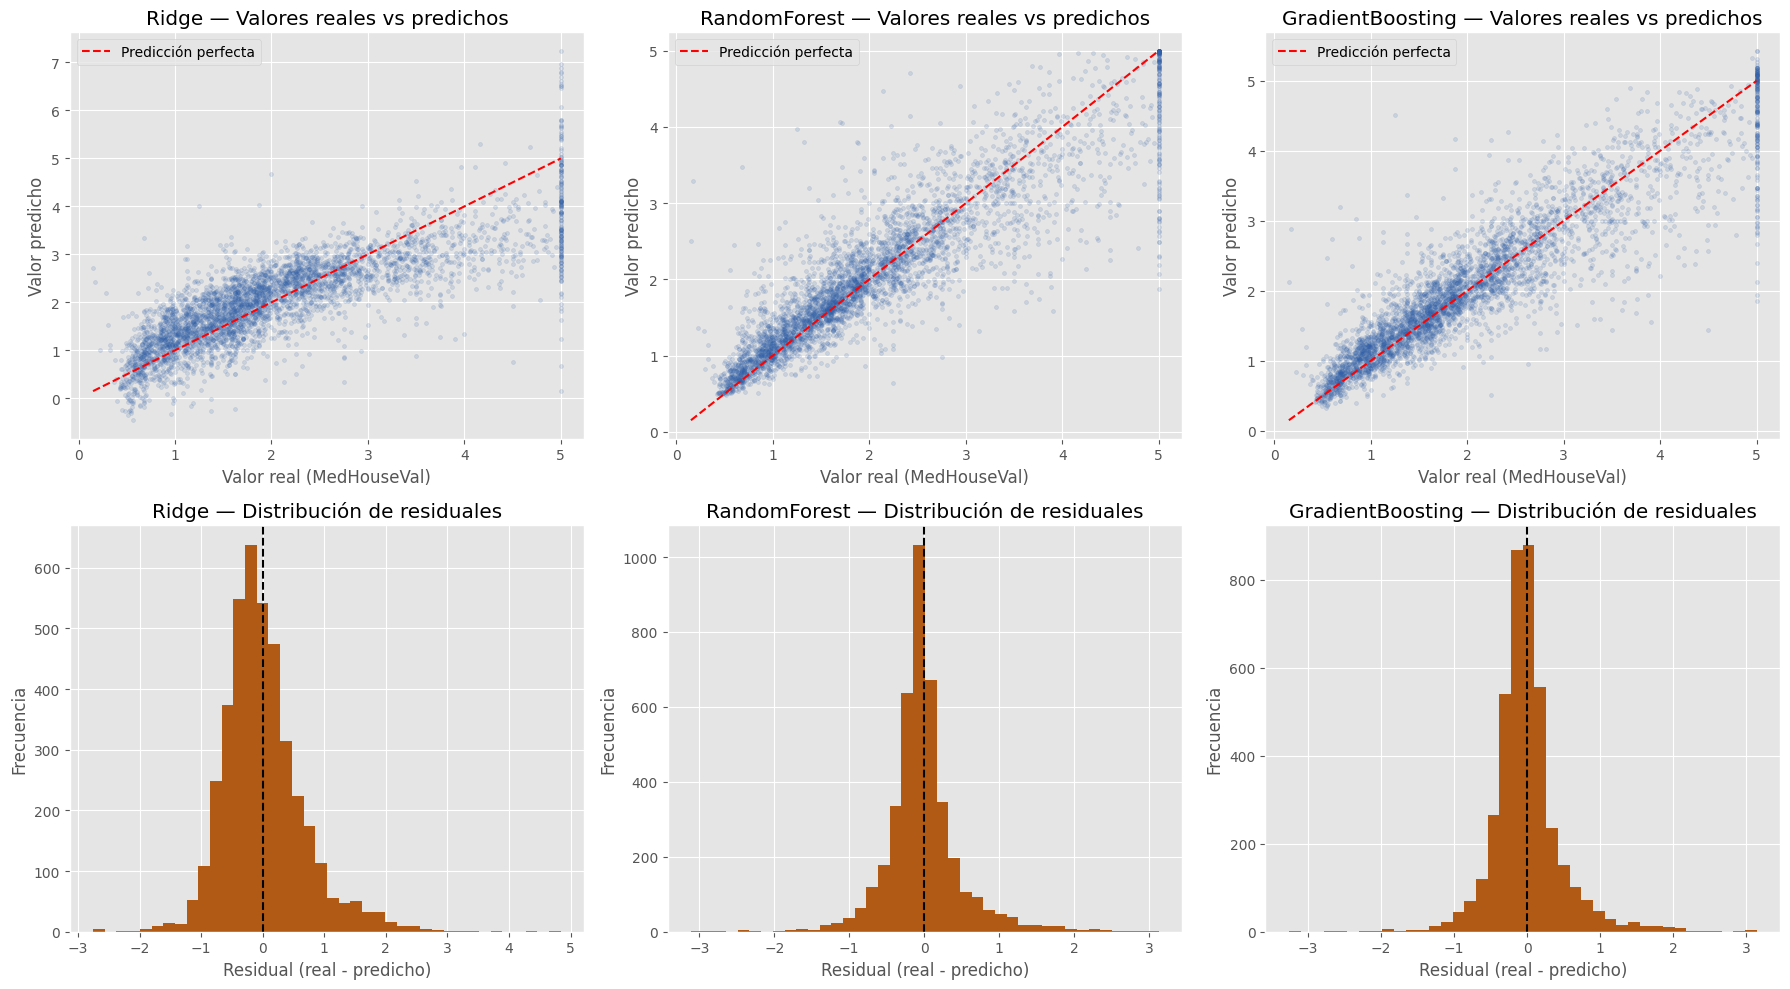

In [26]:
# Diagnóstico visual de los tres modelos
fig, axes = plt.subplots(2, 3, figsize=(18,10))

for i, (nombre, modelo) in enumerate([("Ridge", ridge_best),
                                       ("RandomForest", rf_best),
                                       ("GradientBoosting", gb_best)]):
    y_pred = modelo.predict(X_test_prep)

    # Fila 1: real vs predicho
    axes[0,i].scatter(y_test, y_pred, alpha=0.15, s=8, color="#2F5FA8")
    lims = [y_test.min(), y_test.max()]
    axes[0,i].plot(lims, lims, "r--", label="Predicción perfecta")
    axes[0,i].set_title(f"{nombre} — Valores reales vs predichos")
    axes[0,i].set_xlabel("Valor real (MedHouseVal)")
    axes[0,i].set_ylabel("Valor predicho")
    axes[0,i].legend()

    # Fila 2: histograma de residuales
    residuales = y_test - y_pred
    axes[1,i].hist(residuales, bins=40, color="#B15A16")
    axes[1,i].axvline(0, color="black", linestyle="--")
    axes[1,i].set_title(f"{nombre} — Distribución de residuales")
    axes[1,i].set_xlabel("Residual (real - predicho)")
    axes[1,i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("figures/modelos_diagnostico.png", dpi=150)
plt.show()

Leyendo los tres gráficos de izquierda a derecha se ve la mejora progresiva: la nube de Ridge está muy dispersa, la del Random Forest se aprieta contra la diagonal roja, y la del Gradient Boosting es la más ajustada de las tres.

En Ridge se nota algo que un modelo lineal no puede evitar: **predice valores negativos en 32 distritos** (el mínimo llega a −0.46), cuando el valor real más bajo del test es 0.15. Un precio de vivienda negativo no tiene sentido, y es una limitación estructural de ajustar una recta a un problema que está acotado por abajo. Los dos modelos de árboles no tienen ese problema, porque predicen combinando valores efectivamente observados y nunca se salen del rango real.

En los tres aparece la **franja vertical de puntos en x = 5.0**: son los distritos censurados. Ningún modelo puede acertarles, porque el valor real fue truncado.

Los histogramas de residuales están centrados en cero en los tres casos, así que ninguno tiene sesgo sistemático. Lo que cambia es el ancho: el de Ridge es el más abierto y el de Gradient Boosting el más angosto y puntiagudo, que es exactamente lo que uno quiere ver — errores concentrados cerca de cero.

### Selección del mejor modelo

**Elijo Gradient Boosting**, y lo interesante de esta decisión es que no tuve que ceder en nada: gana en las cuatro métricas, generaliza mejor y además entrena más rápido que el Random Forest.

Tomando el **R² sobre test** como métrica principal, el ranking queda: Gradient Boosting **0.83**, Random Forest **0.81** y Ridge **0.66**. La misma jerarquía se repite en las otras tres métricas — el RMSE baja de 0.67 (Ridge) a 0.50 (bosque) y a **0.47** (boosting), y el MAPE de 29.6% a 19.0% y a **18.2%**. Traducido a dólares, mi error promedio pasa de unos 49 mil con Ridge a unos **31 mil** con Gradient Boosting.

Sobre el **sobreajuste**, la comparación train vs test es lo más revelador del trabajo. Ridge marca 0.68 en train y 0.66 en test: una brecha de apenas **0.02**, generaliza casi perfecto pero su techo es bajo porque el problema no es lineal. El Random Forest se va al otro extremo, con 0.97 en train contra 0.81 en test: una brecha de **0.17** que confirma lo que anticipaba su grilla al elegir árboles sin límite de profundidad — está memorizando buena parte del entrenamiento. El Gradient Boosting queda en el punto medio, con 0.90 en train y 0.83 en test: una brecha de **0.07**, menos de la mitad que el bosque. Es decir, no solo predice mejor, sino que lo que aprendió es más transferible a datos nuevos.

En **tiempo**, Ridge sigue siendo imbatible (fracciones de segundo), pero entre los dos ensambles el boosting resultó **más de dos veces más rápido** que el bosque, porque sus árboles de profundidad 5 son mucho más baratos de construir que los árboles sin tope del Random Forest. En **inferencia** ambos deben recorrer 200 árboles, aunque los del boosting son notoriamente más pequeños.

En **interpretabilidad** Ridge conserva una ventaja real: sus coeficientes indican magnitud *y* dirección del efecto, mientras que los ensambles solo entregan importancia relativa, sin signo. Pero esa ventaja no compensa una diferencia de 0.17 puntos de R².

Como el objetivo aquí es maximizar precisión predictiva y el modelo se entrena una sola vez, **Gradient Boosting es la elección correcta: mejor desempeño, menor sobreajuste y menor costo que su alternativa directa**.

## 13. Importancia de variables

Importancia de cada variable (%):
MedInc           56.16
AveOccup         13.25
Longitude        10.94
Latitude          9.85
HouseAge          4.30
AveRooms          2.83
Population        1.38
AveBedrms         1.02
region_Centro     0.14
region_Sur        0.08
age_group         0.04
region_Norte      0.02
dtype: float64


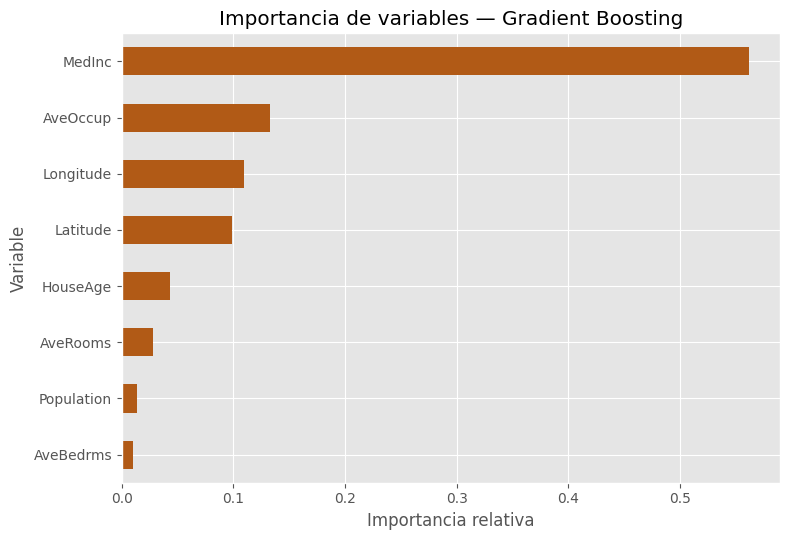

In [27]:
# Uso el mejor modelo: Gradient Boosting
importancias = pd.Series(gb_best.feature_importances_, index=feat_names).sort_values(ascending=False)

print("Importancia de cada variable (%):")
print((importancias*100).round(2))

plt.figure(figsize=(8,5.5))
importancias.head(8).sort_values().plot(kind="barh", color="#B15A16")
plt.title("Importancia de variables — Gradient Boosting")
plt.xlabel("Importancia relativa")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=150)
plt.show()

### Interpretación de las 5 variables más importantes

1. **`MedInc` — 56%.** El ingreso medio del distrito explica por sí solo más de la mitad de las decisiones del modelo. Coincide con el EDA, donde también era la más correlacionada (r = 0.688). En términos de negocio es la conclusión más directa del trabajo: **el poder adquisitivo del barrio es el principal determinante del precio de la vivienda**, muy por encima de las características físicas de las casas.

2. **`AveOccup` — 13%.** Los ocupantes promedio por hogar suben al segundo lugar, cuando en el EDA su correlación lineal era apenas 0.281. Esa diferencia me dice que la relación **no es lineal**: el hacinamiento abarata, pero un hogar con muy pocos ocupantes no encarece de forma proporcional. Un modelo lineal no puede capturar eso; un árbol sí, porque parte la variable en tramos.

3. **`Longitude` — 11%** y **4. `Latitude` — 10%.** Juntas suman cerca de **21%**, lo que las convierte de hecho en el segundo factor más relevante del modelo. Y acá está el contraste más interesante con el EDA: la correlación lineal de `Longitude` con el precio era de apenas **0.046**, prácticamente cero. La ubicación importa muchísimo, pero de forma **no lineal** — lo que encarece no es "estar más al norte" sino estar en zonas específicas (la costa, la Bahía, ciertos barrios), y eso solo se captura con cortes geográficos como los que hacen los árboles.

5. **`HouseAge` — 4%.** Aporta de manera moderada, consistente con lo que vi en el violín: la antigüedad no es determinante por sí sola.

**El contraste más llamativo con el EDA es `AveRooms`:** era la **segunda** variable más correlacionada (r = 0.311) pero cae al **sexto** lugar en importancia real (cerca del 3%). La razón la vi en el scatter de la sección 6: `AveRooms` tiene r = 0.649 con `MedInc`. Es decir, buena parte de lo que "explicaba" era en realidad el ingreso disfrazado. Una vez que el modelo ya usó `MedInc` para dividir los datos, `AveRooms` casi no aporta información nueva. **Correlación alta no implica importancia alta cuando hay redundancia entre predictores.**

Por último, `age_group` y las tres columnas de `region` tienen importancias prácticamente nulas: **suman alrededor de 0.3% entre las cuatro**. Es exactamente lo que esperaba: son versiones agrupadas de `HouseAge` y `Latitude`, que ya están en el modelo con toda su resolución. Las construí para poder aplicar los codificadores que pide la pauta, y su baja importancia confirma que el modelo prefiere la información continua original. Vale notar que el Random Forest les daba un poco más de peso (0.57%); el boosting las descarta todavía más rápido, porque al corregir errores de forma secuencial no gasta divisiones en variables redundantes.

## 14. Análisis de los errores más grandes

In [28]:
# Busco las 10 observaciones donde más me equivoqué, usando el mejor modelo
y_pred_best = gb_best.predict(X_test_prep)
error_abs = np.abs(y_test.values - y_pred_best)
peores_idx = np.argsort(error_abs)[-10:][::-1]

peores = X_test.iloc[peores_idx].copy()
peores["y_real"] = y_test.values[peores_idx]
peores["y_pred"] = y_pred_best[peores_idx].round(3)
peores["error_abs"] = error_abs[peores_idx].round(3)

print(f"Error absoluto medio del modelo: {error_abs.mean():.3f}")
print(f"Error de estas 10 observaciones: entre {error_abs[peores_idx].min():.3f} y {error_abs[peores_idx].max():.3f}")
print(f"\nDistribución por región de las 10 peores:")
print(peores["region"].value_counts())
print(f"\nCuántas de las 10 están en el tope de censura (y_real = 5.0): {(peores['y_real'] >= 5.0).sum()}")

peores

Error absoluto medio del modelo: 0.313
Error de estas 10 observaciones: entre 2.328 y 3.263

Distribución por región de las 10 peores:
region
Sur      8
Norte    2
Name: count, dtype: int64

Cuántas de las 10 están en el tope de censura (y_real = 5.0): 5


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,age_group,region,y_real,y_pred,error_abs
20349,7.3004,32.0,5.724138,0.865909,63.0,2.172414,34.17,-119.08,Media,Sur,1.25000,4.513,3.263
10574,1.9659,6.0,4.795455,1.159091,125.0,2.840909,33.72,-117.70,Nueva,Sur,5.00001,1.861,3.139
12389,3.7727,24.0,8.469878,1.239697,473.0,1.995781,33.75,-116.43,Media,Sur,5.00001,1.934,3.066
19542,1.7679,39.0,5.000000,0.888889,22.0,2.444444,37.63,-120.92,Antigua,Norte,4.50000,1.441,3.059
12069,4.2386,6.0,7.723077,1.169231,228.0,3.507692,33.83,-117.55,Nueva,Sur,5.00001,2.127,2.873
5887,2.3667,39.0,3.572464,1.217391,259.0,1.876812,34.15,-118.33,Antigua,Sur,0.17500,2.877,2.702
20325,4.5833,21.0,7.278431,1.082353,863.0,3.384314,34.28,-119.04,Media,Sur,5.00001,2.403,2.597
4548,7.5752,52.0,3.142857,1.000000,55.0,4.561041,34.02,-118.21,Antigua,Sur,0.67500,3.192,2.517
13015,3.2321,11.0,7.041467,1.153110,1520.0,2.424242,38.71,-121.19,Nueva,Norte,3.90800,1.548,2.360
14463,3.1324,28.0,4.228261,1.239697,770.0,1.394928,32.85,-117.30,Media,Sur,5.00001,2.672,2.328


### Qué tienen en común las 10 peores predicciones

Encontré **dos patrones claros**, y el más importante de los dos ni siquiera es una falla del modelo:

**1. La mitad de los casos está en el tope de censura (`y_real = 5.00001`).** Este es el hallazgo central. En esos distritos el modelo predijo valores del orden de 2, coherentes con el ingreso y el tamaño de las viviendas de la zona, mientras que el valor registrado es 5.0. Pero ese 5.0 **no es el precio verdadero**: es el techo donde el censo truncó todo lo que valía más de 500.001 USD. El modelo no se equivoca, está prediciendo un valor razonable para un dato cuya etiqueta fue recortada artificialmente. Es una **limitación del dataset, no del algoritmo**, y afecta a 992 distritos (4.81% del total) como calculé en la sección 5.

**2. La gran mayoría está en la región Sur.** El Sur (Los Ángeles, San Diego, zona costera) concentra los distritos de mayor valor y también la mayor heterogeneidad interna: barrios carísimos pegados a barrios modestos. Es justamente donde características estadísticas parecidas pueden corresponder a precios muy distintos, y por eso es la zona más difícil de predecir.

El resto de los casos va en la dirección contraria: **valores reales muy bajos en distritos que parecían caros**. Los dos más llamativos tienen `MedInc` de 7.30 y 7.58 — ingresos entre los más altos del dataset — pero valores de vivienda de apenas 1.25 y 0.675. El modelo predijo 4.51 y 3.19 respectivamente, que es lo lógico dado el ingreso. Ahí hay algo que el dataset no registra: probablemente estado de conservación, condiciones del sector o alguna particularidad del barrio que hace que viviendas baratas convivan con ingresos altos.

**Conclusión práctica:** si quisiera mejorar el modelo, el mayor retorno no vendría de seguir ajustando hiperparámetros, sino de **tratar la censura de la variable objetivo** — excluyendo esos distritos del entrenamiento o usando un modelo de regresión censurada.

## 15. Conclusiones ejecutivas

Trabajé con el dataset California Housing (20.640 distritos censales del censo de 1990) para predecir el valor medio de la vivienda a partir de variables socioeconómicas, demográficas y geográficas, aplicando un flujo completo de EDA, preprocesamiento sin fuga de datos, análisis no supervisado y modelado supervisado comparado.

**Hallazgos del EDA.** El dataset llegó limpio en cuanto a completitud: **0% de nulos** en las 11 columnas. Los problemas estaban en otro lado. Detecté *outliers* legítimos pero extremos en cuatro variables (entre **2.48% y 6.90%** de las observaciones), que traté por capping IQR en lugar de eliminarlos, para no perder cobertura geográfica. La variable objetivo mostró un *skewness* de **0.98**, justo bajo el umbral de 1.0, por lo que mantuve la escala original. El hallazgo más relevante fue descubrir que `MedHouseVal` está **censurada en 500.001 USD**, afectando a **992 distritos (4.81% del dataset)**, algo que terminó explicando la mitad de los errores grandes del modelo final. En correlaciones, `MedInc` domina ampliamente (r = 0.688 contra 0.311 de la segunda), y encontré multicolinealidad esperable entre `Latitude` y `Longitude` (r = -0.925), que decidí conservar por ser información posicional útil.

**Patrones del análisis no supervisado.** El PCA redujo las 12 variables preprocesadas a **5 componentes conservando el 86.40%** de la varianza, y separó de forma limpia las dos dimensiones del problema: PC1 quedó dominado por la ubicación y PC2 por el perfil socioeconómico y de vivienda. El K-Means arrojó **K = 2** como óptimo (Silhouette 0.2736), con clusters que se diferencian casi exclusivamente por geografía (Norte con latitud media 37.93 contra Sur con 33.93) y no por ingreso, que resultó prácticamente idéntico entre ambos grupos. El Silhouette moderado me indica que este dataset es más un continuo que un conjunto de segmentos discretos.

**Modelo seleccionado.** Comparé tres modelos y el ganador fue **Gradient Boosting** (`n_estimators=200`, `max_depth=5`, `min_samples_split=5`), con **R² = 0.83, RMSE = 0.47, MAE = 0.31 y MAPE = 18.2%** sobre el test, superando tanto a Random Forest (R² = 0.81) como a Ridge (R² = 0.66). Lo más valioso de esta comparación fue ver las dos familias de ensamble enfrentadas: el *bagging* del Random Forest eligió árboles sin límite de profundidad y terminó con una brecha train-test de **0.17**, mientras que el *boosting* eligió árboles de profundidad 5 y cerró esa brecha a **0.07**, menos de la mitad. Y además entrenó en la mitad del tiempo. Es decir, el boosting no solo predijo mejor: generalizó mejor y costó menos, sin ningún trade-off que negociar.

**Top 3 variables e interpretación de negocio.** (1) `MedInc` con cerca del **56%** de importancia: el poder adquisitivo del barrio es el determinante principal del precio, muy por encima de las características físicas de las viviendas. (2) La ubicación geográfica (`Longitude` + `Latitude`, alrededor de **21%** combinado): lo que encarece no es una dirección cardinal sino zonas específicas, un efecto no lineal que la correlación de Pearson no detectaba (r = 0.046 para longitud). (3) `AveOccup` con cerca del **13%**: la densidad de ocupación afecta el precio, pero de manera asimétrica según el tramo.

**Limitaciones.** Primero, la censura del objetivo en 5.00001 degrada artificialmente el desempeño en los distritos más caros y explica la mitad de mis 10 peores errores. Segundo, los datos son de **1990**, así que las conclusiones no son extrapolables al mercado inmobiliario actual. Tercero, faltan variables que probablemente explicarían el error residual: estado de conservación, tipo de construcción, seguridad del sector o cercanía a la costa — algo que se hizo evidente al encontrar distritos con ingresos altísimos (`MedInc` sobre 7) y viviendas baratísimas, una combinación que ninguna de mis variables puede explicar.

**Recomendaciones.** Primero, tratar explícitamente los valores censurados, ya sea excluyendo esos 992 distritos del entrenamiento o aplicando un modelo de regresión censurada tipo Tobit; es la mejora con mayor retorno esperado, porque ataca la causa de la mitad de los errores grandes. Segundo, si el objetivo fuera llevar esto a producción, descartaría el Random Forest del pipeline: entrega menos precisión, más sobreajuste y más costo que el Gradient Boosting, así que no aporta nada que el boosting no haga mejor.

**Trabajo futuro.** Probar implementaciones de boosting más modernas como **XGBoost o LightGBM**, que suelen superar al `GradientBoostingRegressor` de scikit-learn en velocidad y a veces en precisión (no las usé acá porque no tienen el parámetro `min_samples_split` que exige la pauta), y aplicar **SHAP** para descomponer las predicciones observación por observación, en lugar de quedarme solo con la importancia global de variables.